# Customer Churn Analysis & Prediction

## Project Overview
In this project, we aim to analyze customer data to understand why customers leave a service (churn). Customer churn is a critical problem for businesses because losing customers directly impacts revenue.

## Objective
The main goals of this project are:
- To explore and analyze customer behavior using data
- To identify key factors that influence churn
- To build a machine learning model that can predict whether a customer will churn

## Why This Project?
Understanding customer churn helps companies:
- Improve customer retention strategies
- Identify high-risk customers early
- Make data-driven business decisions

## What We Will Do
- Perform data cleaning and preprocessing
- Conduct exploratory data analysis (EDA)
- Build and evaluate machine learning models
- Generate insights for business decision-making

# 1.Data Loading & Initial Exploration

In this step, we load the dataset and understand its structure.
We check:
- Number of rows and columns
- Data types of each column
- Missing values
- Basic statistics

This helps us understand what kind of data we are working with before cleaning.

In [1]:
import pandas as pd
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Structure Analysis

In this step, we examine the structure of the dataset using `df.info()`.

This helps us:
- Identify data types of each column
- Detect missing values
- Understand overall dataset size

This step is important before data cleaning and preprocessing.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Observations from Dataset

- Dataset contains 7043 rows and 21 columns
- Most columns are categorical (object type)
- Numerical columns include tenure and MonthlyCharges
- The TotalCharges column is incorrectly stored as object instead of numeric
- This indicates possible hidden missing or invalid values

Next step is to clean and convert TotalCharges into proper numeric format

In [3]:
df["TotalCharges"].value_counts()

TotalCharges
20.2      11
          11
19.75      9
19.65      8
19.9       8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
108.15     1
Name: count, Length: 6531, dtype: int64

## Cleaning TotalCharges Column

The TotalCharges column is stored as an object instead of numeric due to blank values.

Steps performed:
- Replace blank values with NaN
- Convert column to numeric type
- Handle missing values

This ensures the column is usable for analysis and modeling.

In [4]:

df["TotalCharges"] = df["TotalCharges"].replace(" ", pd.NA)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

df["TotalCharges"].isnull().sum()

np.int64(11)

## Handling Missing Values

The TotalCharges column contains 11 missing values.
Since the number of missing records is very small compared to the total dataset size, we remove these rows to maintain data quality.
This avoids introducing incorrect values through imputation.

In [5]:
df = df.dropna()
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Removing Irrelevant Columns

The `customerID` column is a unique identifier and does not contribute to analysis or prediction.
Hence, it is removed to improve model performance and avoid unnecessary data.

In [6]:
df = df.drop("customerID", axis=1)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

## Encoding Categorical Variables

Machine learning models cannot process categorical (text) data directly.
In this step, we convert categorical columns into numerical format using encoding techniques.
This allows the model to understand patterns and relationships in the data.

In [14]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


## Converting Boolean Values to Numeric

After encoding, some columns contain boolean values (True/False).
These are converted to 0 and 1 to maintain consistency and ensure compatibility with machine learning models.

In [15]:
df_encoded = df_encoded.astype(int)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29,29,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56,1889,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53,108,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42,1840,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70,151,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


## Churn Distribution Analysis

In this step, we analyze how many customers have churned versus those who have not.

This helps us:
- Understand class distribution
- Identify imbalance in the dataset
- Get the first business insight about customer retention

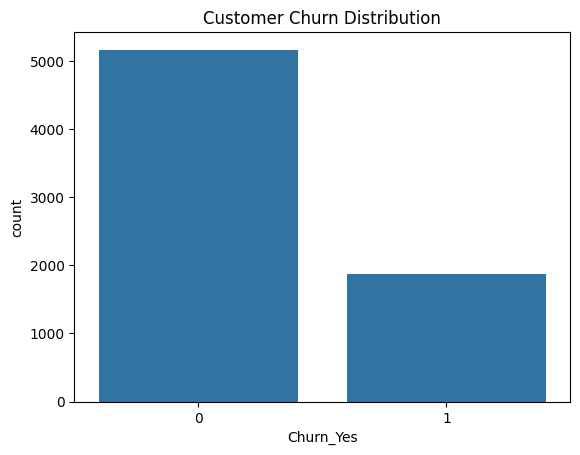

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn_Yes', data=df_encoded)

plt.title("Customer Churn Distribution")
plt.show()

### Insight

The number of customers who did not churn is significantly higher than those who churned.

This indicates a class imbalance in the dataset, which is common in real-world scenarios. 
Such imbalance can affect model performance, so evaluation metrics beyond accuracy will be important.

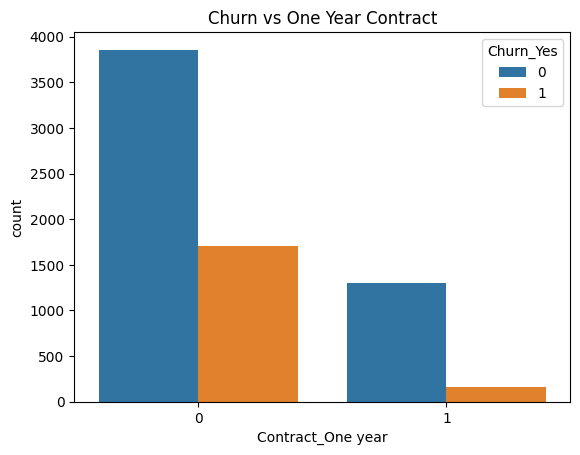

In [19]:
sns.countplot(x='Contract_One year', hue='Churn_Yes', data=df_encoded)

plt.title("Churn vs One Year Contract")
plt.show()

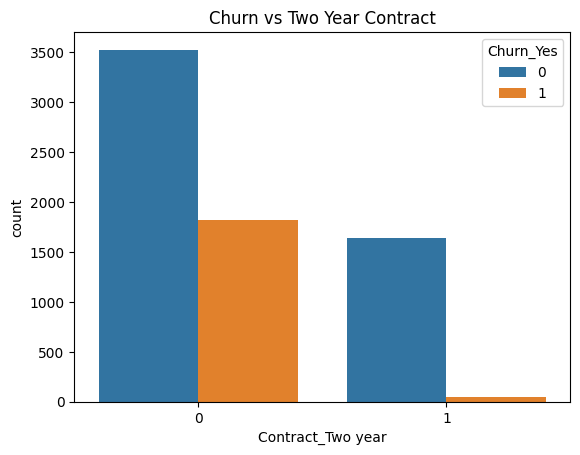

In [20]:
sns.countplot(x='Contract_Two year', hue='Churn_Yes', data=df_encoded)

plt.title("Churn vs Two Year Contract")
plt.show()

### Insight

Customers with month-to-month contracts have the highest churn rate.
Customers with one-year contracts show reduced churn, while those with two-year contracts have the lowest churn rate.
This indicates that longer contract commitments significantly improve customer retention.

## Monthly Charges vs Churn

This analysis helps us understand whether customers with higher monthly charges are more likely to churn.
This is important for identifying revenue risk.

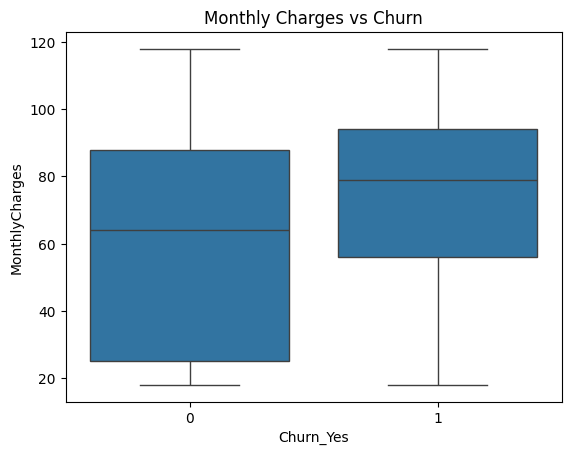

In [21]:
sns.boxplot(x='Churn_Yes', y='MonthlyCharges', data=df_encoded)

plt.title("Monthly Charges vs Churn")
plt.show()

### Insight

Customers who churn tend to have higher monthly charges compared to those who stay.
This suggests that higher pricing may contribute to customer dissatisfaction and increase the likelihood of churn.
Businesses should consider pricing strategies or value-added services to retain high-paying customers.

## Tenure vs Churn

This analysis helps us understand how the length of customer relationship (tenure) affects churn.
It is expected that customers with lower tenure are more likely to churn.

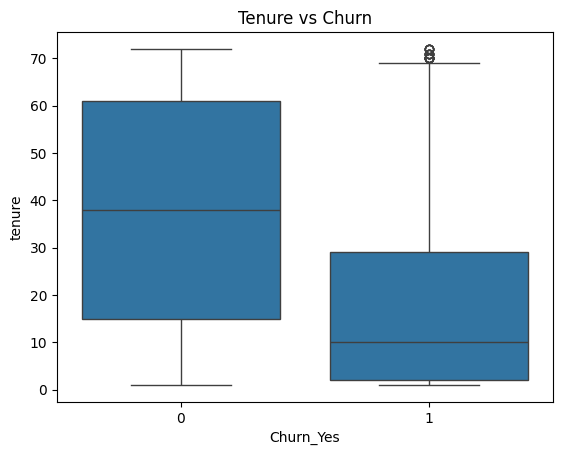

In [22]:
sns.boxplot(x='Churn_Yes', y='tenure', data=df_encoded)

plt.title("Tenure vs Churn")
plt.show()

### Insight

Customers with lower tenure have a significantly higher churn rate compared to long-term customers.
This indicates that most customers leave during the early stages of their relationship with the company.
Improving onboarding and early customer experience can help reduce churn.

## Saving Cleaned Dataset

The cleaned dataset is saved for future use in modeling and visualization.
This avoids repeating preprocessing steps and ensures consistency across the project.

In [30]:
import os
os.getcwd()

'j:\\OneDrive\\Desktop\\ved soman\\python files\\customer-churn-analysis\\Notebooks'

In [35]:
df_encoded.to_csv("j:\\OneDrive\\Desktop\\ved soman\\python files\\customer-churn-analysis\\Notebooks\\cleaned_churn.csv", index=False)
print("Cleaned data saved to cleaned_churn.csv")

Cleaned data saved to cleaned_churn.csv


In [38]:
df.to_csv("j:\\OneDrive\\Desktop\\ved soman\\python files\\customer-churn-analysis\\Notebooks\\churn_cleaned_readable.csv", index=False)
print("Readable cleaned data saved to churn_cleaned_readable.csv for Power BI")

Readable cleaned data saved to churn_cleaned_readable.csv for Power BI
